In [6]:
!pip install textblob
!pip install vaderSentiment
!pip install wordcloud


In [7]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from wordcloud import WordCloud
from textblob import TextBlob
from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer


In [8]:
sns.set(style="whitegrid")

In [9]:
try:
    df = pd.read_csv("/content/Student_Satisfaction_Survey.csv", encoding='latin1', encoding_errors='ignore')
    display(df.head())
except UnicodeDecodeError:
    print("Could not decode the file using 'latin1' encoding. Please try a different encoding.")

,SN,Total Feedback Given,Total Configured,Questions,Weightage 1,Weightage 2,Weightage 3,Weightage 4,Weightage 5,Average/ Percentage,Course Name,Basic Course
0,1,1,12,How much of the syllabus was covered in the cl...,0,0,1,0,0,3.00 / 60.00,FY B.VOC FOOD TECHNOLOGY,B.VOC FOOD TECHNOLOGY
1,2,1,12,How well did the teachers prepare for the clas...,0,0,0,0,1,5.00 / 100.00,FY B.VOC FOOD TECHNOLOGY,B.VOC FOOD TECHNOLOGY
2,3,1,12,How well were the teachers able to communicate?,0,0,0,0,1,5.00 / 100.00,FY B.VOC FOOD TECHNOLOGY,B.VOC FOOD TECHNOLOGY
3,4,1,12,The teachers approach to teaching can best be...,0,0,1,0,0,3.00 / 60.00,FY B.VOC FOOD TECHNOLOGY,B.VOC FOOD TECHNOLOGY
4,5,1,12,Fairness of the internal evaluation process by...,0,0,0,1,0,4.00 / 80.00,FY B.VOC FOOD TECHNOLOGY,B.VOC FOOD TECHNOLOGY


In [10]:
df.info()
display(df.isnull().sum())


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 580 entries, 0 to 579
Data columns (total 12 columns):
 #   Column                Non-Null Count  Dtype 
---  ------                --------------  ----- 
 0   SN                    580 non-null    int64 
 1   Total Feedback Given  580 non-null    int64 
 2   Total Configured      580 non-null    int64 
 3   Questions             580 non-null    object
 4   Weightage 1           580 non-null    int64 
 5   Weightage 2           580 non-null    int64 
 6   Weightage 3           580 non-null    int64 
 7   Weightage 4           580 non-null    int64 
 8   Weightage 5           580 non-null    int64 
 9   Average/ Percentage   580 non-null    object
 10  Course Name           580 non-null    object
 11  Basic Course          580 non-null    object
dtypes: int64(8), object(4)
memory usage: 54.5+ KB


,0
SN,0
Total Feedback Given,0
Total Configured,0
Questions,0
Weightage 1,0
Weightage 2,0
Weightage 3,0
Weightage 4,0
Weightage 5,0
Average/ Percentage,0


In [11]:
display(df.describe())

,SN,Total Feedback Given,Total Configured,Weightage 1,Weightage 2,Weightage 3,Weightage 4,Weightage 5
count,580.000000,580.000000,580.000000,580.000000,580.000000,580.000000,580.000000,580.000000
mean,10.500000,14.310345,92.517241,0.527586,1.187931,2.537931,5.082759,4.974138
std,5.771259,16.488031,114.491780,1.305336,1.686334,3.193302,7.288293,6.494931
min,1.000000,1.000000,12.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,5.750000,3.000000,20.000000,0.000000,0.000000,0.000000,1.000000,1.000000
50%,10.500000,7.000000,42.000000,0.000000,0.000000,1.000000,3.000000,3.000000
75%,15.250000,17.000000,123.000000,1.000000,2.000000,3.250000,6.000000,6.000000
max,20.000000,74.000000,559.000000,19.000000,8.000000,26.000000,52.000000,38.000000


count    580.000000
mean      76.855690
std       12.578606
min       26.670000
25%       70.000000
50%       78.330000
75%       85.000000
max      100.000000
Name: Average_Percentage_Numerical, dtype: float64


/tmp/ipython-input-2743975679.py:12: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  sns.histplot(data=df, x='Average_Percentage_Numerical', palette="coolwarm")


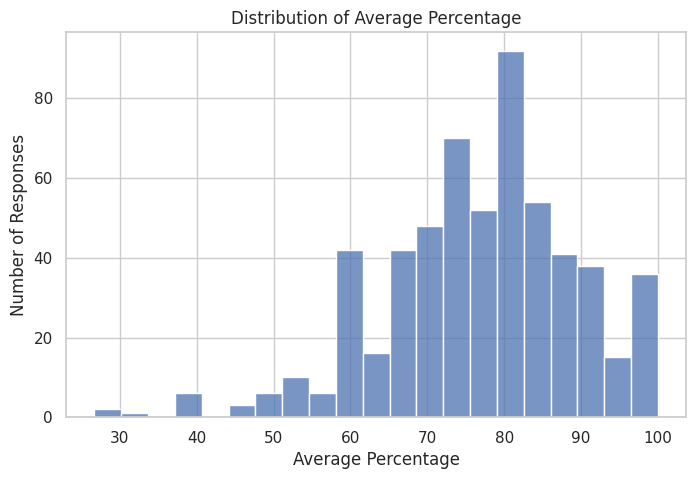

In [12]:
# Replace 'rating' with the correct column name for your scale
rating_col = 'Average/ Percentage'
# Extract the numerical part from the 'average/_percentage' column
df['Average_Percentage_Numerical'] = df[rating_col].str.split('/').str[1].str.strip().astype(float)


# Basic statistics
print(df['Average_Percentage_Numerical'].describe())

# Bar plot
plt.figure(figsize=(8,5))
sns.histplot(data=df, x='Average_Percentage_Numerical', palette="coolwarm")
plt.title("Distribution of Average Percentage")
plt.xlabel("Average Percentage")
plt.ylabel("Number of Responses")
plt.show()


<function matplotlib.pyplot.show(close=None, block=None)>

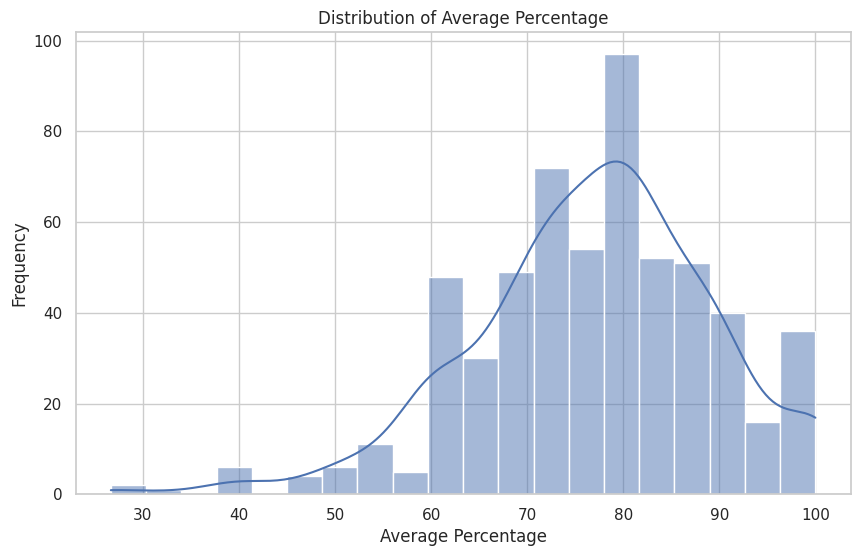

In [13]:
df['Average_Percentage_Numerical'] = df['Average/ Percentage'].str.split('/').str[1].str.strip().astype(float)

# Create a histogram of the numerical 'Average/ Percentage'
plt.figure(figsize=(10, 6))
sns.histplot(df['Average_Percentage_Numerical'], kde=True, bins=20)
plt.title('Distribution of Average Percentage')
plt.xlabel('Average Percentage')
plt.ylabel('Frequency')
plt.show

/tmp/ipython-input-3375097075.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='sentiment', palette='Set2')


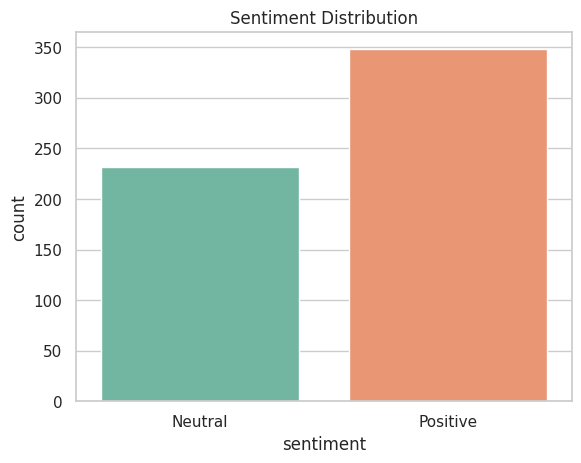

In [14]:
# Initialize VADER sentiment analyzer
analyzer = SentimentIntensityAnalyzer()

# Apply sentiment scores
def get_sentiment(text):
    score = analyzer.polarity_scores(str(text))['compound']
    if score >= 0.05:
        return 'Positive'
    elif score <= -0.05:
        return 'Negative'
    else:
        return 'Neutral'

df['sentiment'] = df['Questions'].apply(get_sentiment)

# Plot sentiment results
sns.countplot(data=df, x='sentiment', palette='Set2')
plt.title('Sentiment Distribution')
plt.show()

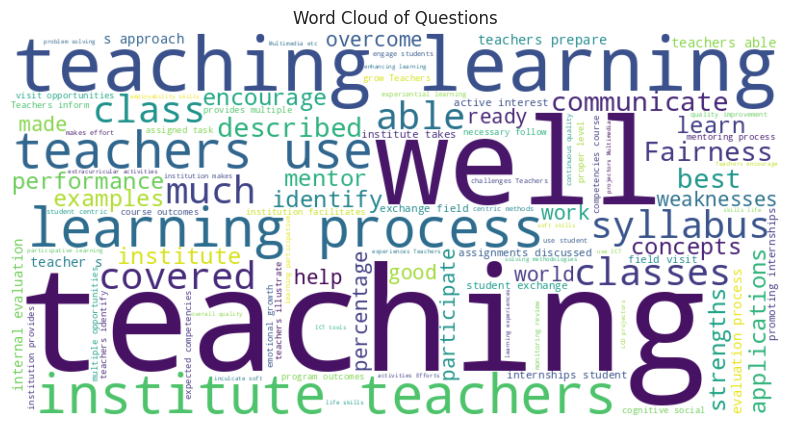

In [15]:
text = ' '.join(str(comment) for comment in df['Questions'].dropna())
wordcloud = WordCloud(width=800, height=400, background_color='white').generate(text)

plt.figure(figsize=(10, 5))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.title("Word Cloud of Questions")
plt.show()

In [ ]:
display(df['sentiment'].value_counts())

,count
sentiment,
Positive,348
Neutral,232


In [16]:
# Group by sentiment to see what students are saying
positive_feedback = df[df['sentiment'] == 'Positive']['Questions'].dropna().tolist()
negative_feedback = df[df['sentiment'] == 'Negative']['Questions'].dropna().tolist()

print("👍 Positive Feedback Examples:\n")
for comment in positive_feedback[:5]:
    print("•", comment)

print("\n⚠️ Negative Feedback Examples:\n")
for comment in negative_feedback[:5]:
    print("•", comment)

👍 Positive Feedback Examples:

• How well did the teachers prepare for the classes?
• How well were the teachers able to communicate?
• The teachers approach to teaching can best be described as
• The institute takes an active interest in promoting internships, student exchange, field visit opportunities for students.
• The teaching and mentoring process in your institution facilitates you in cognitive, social and
emotional growth.

⚠️ Negative Feedback Examples:



In [17]:
# Initialize VADER sentiment intensity analyzer
analyzer = SentimentIntensityAnalyzer()

# Function to get TextBlob sentiment polarity
def get_textblob_sentiment(text):
    return TextBlob(text).sentiment.polarity

# Function to get VADER sentiment score
def get_vader_sentiment(text):
    score = analyzer.polarity_scores(text)
    return score['compound']

# Apply sentiment analysis
df['TextBlob_Sentiment'] = df['Questions'].apply(get_textblob_sentiment)
df['VADER_Sentiment'] = df['Questions'].apply(get_vader_sentiment)

display(df[['Questions', 'TextBlob_Sentiment', 'VADER_Sentiment']].head())

,Questions,TextBlob_Sentiment,VADER_Sentiment
0,How much of the syllabus was covered in the cl...,0.2,0.0000
1,How well did the teachers prepare for the clas...,0.0,0.2732
2,How well were the teachers able to communicate?,0.5,0.2732
3,The teachers approach to teaching can best be...,1.0,0.6369
4,Fairness of the internal evaluation process by...,0.0,0.0000


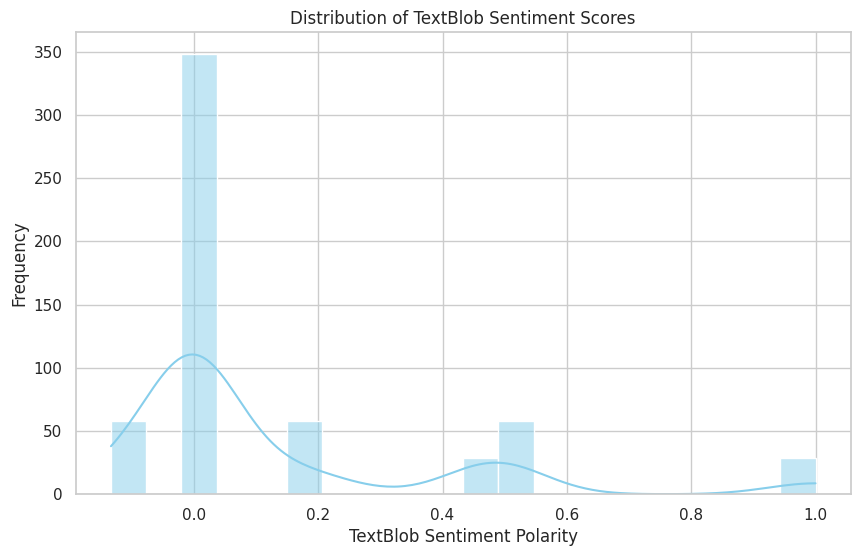

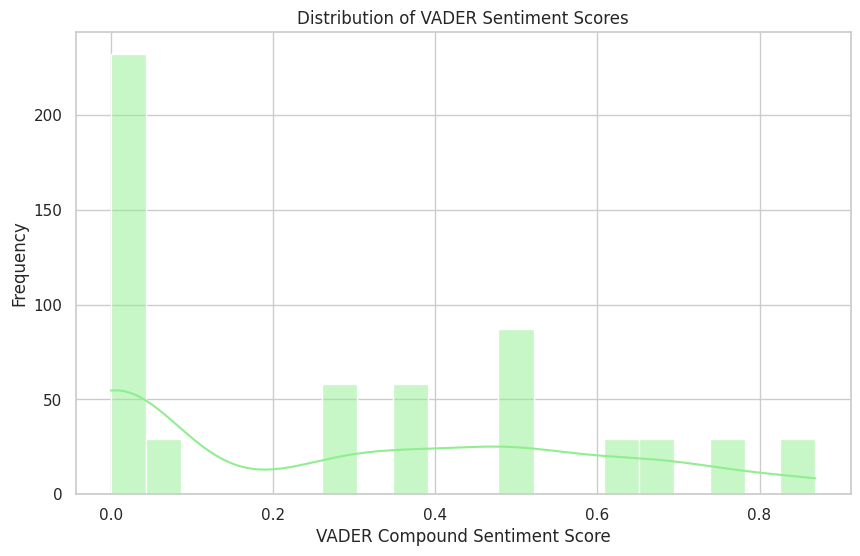

In [18]:

# Visualize TextBlob sentiment distribution
plt.figure(figsize=(10, 6))
sns.histplot(df['TextBlob_Sentiment'], kde=True, bins=20, color='skyblue')
plt.title('Distribution of TextBlob Sentiment Scores')
plt.xlabel('TextBlob Sentiment Polarity')
plt.ylabel('Frequency')
plt.show()

# Visualize VADER sentiment distribution
plt.figure(figsize=(10, 6))
sns.histplot(df['VADER_Sentiment'], kde=True, bins=20, color='lightgreen')
plt.title('Distribution of VADER Sentiment Scores')
plt.xlabel('VADER Compound Sentiment Score')
plt.ylabel('Frequency')
plt.show()

In [19]:
!pip install fpdf

from fpdf import FPDF
import re

class FeedbackReport(FPDF):
    def header(self):
        self.set_font("Arial", "B", 14)
        self.cell(200, 10, "Student Event Feedback Analysis Report", ln=True, align="C")
        self.ln(10)

    def footer(self):
        self.set_y(-15)
        self.set_font("Arial", "I", 8)
        self.cell(0, 10, f"Page {self.page_no()}", align="C")

    def chapter_title(self, title):
        self.set_font("Arial", "B", 12)
        self.set_fill_color(200, 220, 255)
        self.cell(0, 10, title, ln=True, fill=True)
        self.ln(2)

    def chapter_body(self, body):
        # Remove non-latin-1 characters
        cleaned_body = re.sub(r'[^\x00-\x7F]+', ' ', body)
        self.set_font("Arial", "", 11)
        self.multi_cell(0, 10, cleaned_body)
        self.ln()

pdf = FeedbackReport()
pdf.add_page()

pdf.chapter_title("1. Introduction")
pdf.chapter_body("This report analyzes student satisfaction and feedback from a recent event using ratings and comment sentiment analysis.")

pdf.chapter_title("2. Ratings Analysis")
pdf.chapter_body("We used a 1–5 Likert scale. Most students rated the event positively (4 or 5).")

pdf.chapter_title("3. Sentiment Analysis")
pdf.chapter_body("Using NLP (VADER), we identified overall sentiment in textual feedback: mostly Positive, with some Neutral and a few Negative.")

pdf.chapter_title("4. Key Insights")
pdf.chapter_body("Students enjoyed the sessions and speakers. Some reported confusion about the event schedule.")

pdf.chapter_title("5. Recommendations")
pdf.chapter_body("Improve pre-event communication. Add more interactive segments. Extend Q&A sessions.")

# Change output destination to 'S' for string
pdf_output_string = pdf.output(dest="S").encode('latin-1', 'ignore')

# You can then write the string to a file
with open("Event_Feedback_Report.pdf", "wb") as f:
    f.write(pdf_output_string)

print("PDF generated successfully!")

  Preparing metadata (setup.py) ... done
  Created wheel for fpdf: filename=fpdf-1.7.2-py2.py3-none-any.whl size=40704 sha256=d9d623f3fb41ebf736222902f598ce5d11bfa00f3d6776a4dbb7d53d4087c7a6
  Stored in directory: /root/.cache/pip/wheels/6e/62/11/dc73d78e40a218ad52e7451f30166e94491be013a7850b5d75
Successfully built fpdf
PDF generated successfully!
